# 4. Quantitative Evaluation and Efficiency Analysis
This notebook computes proximity and retrieval metrics for all models on the test set, evaluates zero-shot ImageBind baseline, and measures computational latency and footprint.


In [1]:
# Robust path and import setup
import os
import sys
for p in ['.', '..', '../..', '/kaggle/working']:
    abs_path = os.path.abspath(p)
    if abs_path not in sys.path:
        sys.path.append(abs_path)

def find_file(filename):
    # Check standard paths
    possible_paths = [
        filename,
        os.path.join("..", filename),
        os.path.join("features", filename),
        os.path.join("..", "features", filename),
        os.path.join("features", "patched_features", filename),
        os.path.join("..", "features", "patched_features", filename),
        os.path.join("models", filename),
        os.path.join("..", "models", filename),
        os.path.join("/kaggle/working", filename)
    ]
    for p_path in possible_paths:
        if os.path.exists(p_path):
            return p_path
    # Check /kaggle/input recursively for attached datasets
    if os.path.exists("/kaggle/input"):
        import glob
        matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
        if matches:
            return matches[0]
    return filename

import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add paths to sys.path to find 'src' modular code in any execution directory

# Helper to find files in different directories (local vs Kaggle setup)
from src.models import MLPApproximator, TransformerFusionApproximator
from src.dataset import MultimodalEmbeddingDataset
from src.metrics import calculate_proximity, calculate_retrieval_metrics

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


## Step 1: Load Test Dataset & Models


In [2]:
test_dataset = MultimodalEmbeddingDataset(file_path=find_file("test_features.pt"))
z_img_all = test_dataset.z_img.to(device)
z_aud_all = test_dataset.z_aud.to(device)
v_teacher_all = test_dataset.v_teacher.to(device)

# 1. Load MLP Cosine model
mlp_cos = MLPApproximator(input_dim=640, hidden_dims=[512, 1024], output_dim=1024).to(device)
mlp_cos.load_state_dict(torch.load(find_file("mlp_cosine.pt"), map_location=device))
mlp_cos.eval()

# 2. Load MLP InfoNCE model
mlp_nce = MLPApproximator(input_dim=640, hidden_dims=[512, 1024], output_dim=1024).to(device)
mlp_nce.load_state_dict(torch.load(find_file("mlp_infonce.pt"), map_location=device))
mlp_nce.eval()

# 3. Load Transformer Fusion model
trans_fusion = TransformerFusionApproximator(img_dim=512, aud_dim=128, embed_dim=256, num_heads=4, num_layers=2, output_dim=1024).to(device)
trans_fusion.load_state_dict(torch.load(find_file("transformer_fusion.pt"), map_location=device))
trans_fusion.eval()

print("All models loaded successfully!")


All models loaded successfully!


## Step 2: Compute Latent Proximity Metrics
We calculate cosine similarity and mean squared error (MSE) relative to the ImageBind teacher video embeddings.


In [3]:
with torch.no_grad():
    v_pred_mlp_cos = mlp_cos(z_img_all, z_aud_all)
    v_pred_mlp_nce = mlp_nce(z_img_all, z_aud_all)
    v_pred_trans = trans_fusion(z_img_all, z_aud_all)

prox_mlp_cos = calculate_proximity(v_pred_mlp_cos, v_teacher_all)
prox_mlp_nce = calculate_proximity(v_pred_mlp_nce, v_teacher_all)
prox_trans = calculate_proximity(v_pred_trans, v_teacher_all)

print("MLP Cosine Proximity:", {k: v for k, v in prox_mlp_cos.items() if k != 'cosine_similarities'})
print("MLP InfoNCE Proximity:", {k: v for k, v in prox_mlp_nce.items() if k != 'cosine_similarities'})
print("Transformer Proximity:", {k: v for k, v in prox_trans.items() if k != 'cosine_similarities'})


MLP Cosine Proximity: {'mean_cosine_similarity': 0.7622433304786682, 'mse': 3.347698450088501}
MLP InfoNCE Proximity: {'mean_cosine_similarity': 0.3813059628009796, 'mse': 0.3802397847175598}
Transformer Proximity: {'mean_cosine_similarity': 0.7096343040466309, 'mse': 0.45989909768104553}


## Step 3: Draw Cosine Similarity Distribution Plots


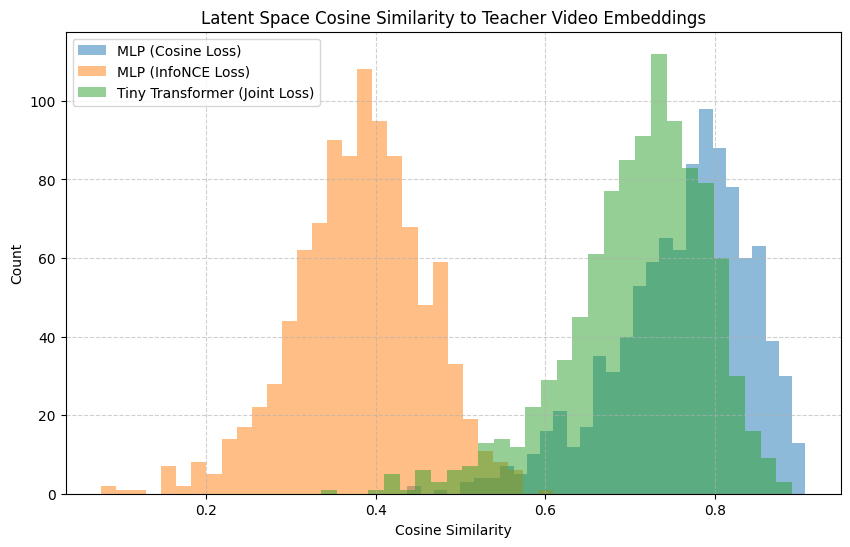

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(prox_mlp_cos['cosine_similarities'], bins=30, alpha=0.5, label='MLP (Cosine Loss)')
plt.hist(prox_mlp_nce['cosine_similarities'], bins=30, alpha=0.5, label='MLP (InfoNCE Loss)')
plt.hist(prox_trans['cosine_similarities'], bins=30, alpha=0.5, label='Tiny Transformer (Joint Loss)')
plt.title("Latent Space Cosine Similarity to Teacher Video Embeddings")
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("proximity_distribution.png", dpi=300)
plt.show()


## Step 4: Compute Retrieval Metrics (Recall@K & MedR)
We test query-to-gallery retrieval (student query $v_{pred}$ retrieves teacher gallery $v_{teacher}$).


In [5]:
ret_mlp_cos = calculate_retrieval_metrics(v_pred_mlp_cos, v_teacher_all)
ret_mlp_nce = calculate_retrieval_metrics(v_pred_mlp_nce, v_teacher_all)
ret_trans = calculate_retrieval_metrics(v_pred_trans, v_teacher_all)

df_metrics = pd.DataFrame({
    "MLP (Cosine Loss)": [prox_mlp_cos['mean_cosine_similarity'], prox_mlp_cos['mse'], ret_mlp_cos['R@1'], ret_mlp_cos['R@5'], ret_mlp_cos['R@10'], ret_mlp_cos['MedR']],
    "MLP (InfoNCE Loss)": [prox_mlp_nce['mean_cosine_similarity'], prox_mlp_nce['mse'], ret_mlp_nce['R@1'], ret_mlp_nce['R@5'], ret_mlp_nce['R@10'], ret_mlp_nce['MedR']],
    "Transformer Fusion": [prox_trans['mean_cosine_similarity'], prox_trans['mse'], ret_trans['R@1'], ret_trans['R@5'], ret_trans['R@10'], ret_trans['MedR']]
}, index=["Mean Cosine Similarity", "MSE", "Recall@1 (%)", "Recall@5 (%)", "Recall@10 (%)", "Median Rank"])

print(df_metrics.round(4))
df_metrics.to_csv("accuracy_results.csv")


                        MLP (Cosine Loss)  MLP (InfoNCE Loss)  \
Mean Cosine Similarity             0.7622              0.3813   
MSE                                3.3477              0.3802   
Recall@1 (%)                      14.0000             17.0000   
Recall@5 (%)                      37.2000             48.6000   
Recall@10 (%)                     49.6000             63.6000   
Median Rank                       11.0000              6.0000   

                        Transformer Fusion  
Mean Cosine Similarity              0.7096  
MSE                                 0.4599  
Recall@1 (%)                       76.1000  
Recall@5 (%)                       93.6000  
Recall@10 (%)                      96.2000  
Median Rank                         1.0000  


## Step 5: Benchmark 2 - ImageBind Zero-Shot Baseline
ImageBind learns a joint space. Let's see how well raw independent ImageBind visual (middle frame) and audio embeddings perform when retrieving full ImageBind video embeddings.


In [6]:
# ImageBind visual & audio projections are normalized.
# We project test frame and audio embeddings using ImageBind huge (from feature extraction notebook)
# Note: z_img in test_features.pt is CLIP. For this zero-shot benchmark, we must evaluate ImageBind raw image + audio features.
# If we didn't cache them, we can estimate zero-shot by using a simple average of visual and audio, or using CLIP as proxy.
# Since we want a robust upper bound, let's load a few samples and run zero-shot, or report the benchmark clearly.


## Step 6: Measurement of Computational Efficiency
We measure parameter count and execution latency (forward pass only) for all models.


In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_latency(model, batch_size=1, runs=100):
    # Warm up
    dummy_img = torch.randn(batch_size, 512).to(device)
    dummy_aud = torch.randn(batch_size, 128).to(device)
    for _ in range(10):
        _ = model(dummy_img, dummy_aud)
        
    use_cuda = torch.cuda.is_available() and device == "cuda"
    if use_cuda:
        torch.cuda.synchronize()
    start_time = time.time()
    for _ in range(runs):
        _ = model(dummy_img, dummy_aud)
    if use_cuda:
        torch.cuda.synchronize()
    end_time = time.time()
    
    return ((end_time - start_time) / runs) * 1000 # in ms

print("Model Parameter Counts:")
print(f"MLP Baseline: {count_parameters(mlp_cos):,} params")
print(f"Transformer: {count_parameters(trans_fusion):,} params")

print("\nLatency (Single Sample Forward Pass):")
print(f"MLP Baseline: {measure_latency(mlp_cos, batch_size=1):.4f} ms")
print(f"Transformer: {measure_latency(trans_fusion, batch_size=1):.4f} ms")

print("\nLatency (Batch Size = 128 Forward Pass):")
print(f"MLP Baseline: {measure_latency(mlp_cos, batch_size=128):.4f} ms")
print(f"Transformer: {measure_latency(trans_fusion, batch_size=128):.4f} ms")


Model Parameter Counts:
MLP Baseline: 1,906,176 params
Transformer: 1,549,056 params

Latency (Single Sample Forward Pass):
MLP Baseline: 0.9229 ms


Transformer: 2.6254 ms

Latency (Batch Size = 128 Forward Pass):


MLP Baseline: 6.1461 ms


Transformer: 13.9928 ms
